# **Project Name**    - Classification -Flipkart Customer Service Satisfaction



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 - Naveen Rana**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

**Objective:-**

This project aims to classify Customer Satisfaction Scores (CSAT) using historical customer support interaction data. CSAT is a critical metric for evaluating service quality and customer experience. By analyzing past interactions, agent behavior, customer remarks, and ticket resolution times, we build a classification model to predict the level of customer satisfaction (1 to 5). This model will help proactively identify areas needing improvement and optimize support workflows.


**Dataset Overview:-**

The dataset, Customer_support_data.csv, contains multiple entries from a customer support system. Each row represents a unique customer interaction along with metadata such as agent details, time of response, product details, and the final satisfaction score. The goal is to use these features to predict the CSAT Score, which ranges from 1 (very dissatisfied) to 5 (very satisfied).

**Feature-wise Explanation:-**

**Unique id:** A unique identifier for each customer support ticket. Used for tracking, not used in modeling.

**channel_name:** The communication channel used by the customer (e.g., Email, Chat, Phone), which influences response quality and time.

**category:** Broad classification of the support issue (e.g., Technical, Billing, Account), useful in understanding issue trends.

**Sub-category:** More specific issue label under each category (e.g., "Login Failure" under Technical) to capture granular insights.

**Customer Remarks:** Free-text input from customers about their issue; useful for sentiment analysis or NLP-based features.

**Order_id:** The ID of the order associated with the issue; may not be directly useful unless joined with order metadata.

**order_date_time:** Timestamp of the order; can be used to derive delays or time gaps relative to issue date.

**Issue_reported at:** Time when the customer reported the issue; helps calculate response and resolution delays.

**issue_responded:** Time when the support agent responded; combined with report time to calculate response duration.

**Survey_response_Date:** Date when customer gave the CSAT feedback; useful to understand follow-up timing, but not always predictive.

**Customer_City:** The city where the customer resides; can identify location-based trends or systemic issues.

**Product_category:** The type of product involved in the support ticket; some product types may result in higher or lower CSAT.

**Item_price:** Price of the item involved; higher prices might lead to higher customer expectations and affect satisfaction.

**connected_handling_time:** Total time spent by the agent resolving the issue; excessive durations may signal complexity or inefficiency.

**Agent_name:** Name of the support agent handling the ticket; can be encoded to understand individual performance impact.

**Supervisor:** The agent’s supervisor; useful to analyze team-level trends in CSAT.

**Manager:** The manager overseeing the support process; can help identify management-level influence on support quality.

**Tenure Bucket:** Agent experience group (e.g., 0–6 months, 6–12 months); more experienced agents might resolve issues better.

**Agent Shift:** Time shift during which the case was handled (e.g., Day, Night); night shifts might see different trends in CSAT.

**CSAT Score (Target Variable):** Customer satisfaction score (1 to 5); the main variable we aim to classify using other features.


**Use Case:-**

This classification model can be used by customer service teams to:

*   Flag at-risk tickets likely to receive low CSAT scores.
*   Identify factors leading to dissatisfaction.
*   Guide training and resource allocation to improve service quality.

# **GitHub Link -**

https://github.com/nkr2021/flipkart-project-CSAT

# **Problem Statement**


In today's competitive environment, delivering exceptional customer support is critical to retaining customers and sustaining business growth. Organizations rely heavily on Customer Satisfaction Scores (CSAT) to evaluate their support effectiveness and service quality. However, collecting CSAT feedback post-interaction is reactive and often too late to intervene in the customer experience process.

This project aims to build a machine learning classification model that can predict customer satisfaction (CSAT scores ranging from 1 to 5) based on past customer support interactions. By analyzing structured data such as ticket handling time, agent performance, issue type, and metadata like time and location, we seek to identify patterns that lead to high or low satisfaction outcomes.

#### **Define Your Business Objective?**

The objective of the business is to proactively predict customer dissatisfaction and take early action to improve the overall service experience. The insights generated can help customer support teams enhance operational efficiency, allocate resources better, and ultimately increase customer loyalty.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd  # Data manipulation
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Advanced data visualization
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score  # Model selection tools
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Data preprocessing
from sklearn.ensemble import RandomForestClassifier  # Ensemble model
from xgboost import XGBClassifier  # XGBoost model
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score  # Evaluation metrics
import warnings  # Handling warnings
warnings.filterwarnings('ignore') # Suppress all warnings for clean output

### Dataset Loading

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/My Drive/Innovexis project 1/Customer_support_data.csv')

Mounted at /content/drive


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
shape = df.shape
print(f"Number of Rows  = {shape[0]}")
print(f"Number of Columns  = {shape[1]}")

Number of Rows  = 85907
Number of Columns  = 20


### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(f"Number of duplicate values = {df.duplicated().sum()}")

Number of duplicate values = 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


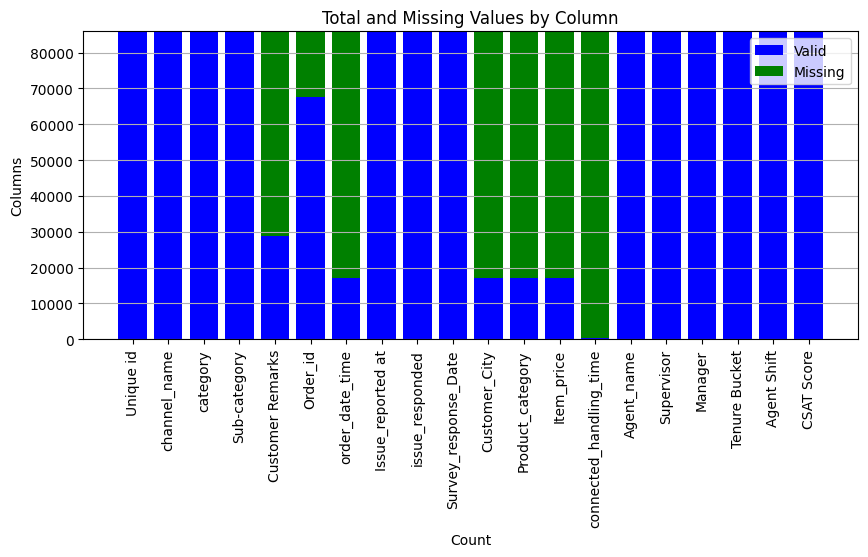

In [ ]:
# Visualizing the missing values
# Calculate total and missing counts for each column
total_counts = len(df)
missing_counts = df.isnull().sum()

# Calculate valid counts by subtracting missing from total
valid_counts = total_counts - missing_counts

# Plot the stacked bar chart for valid and missing values
plt.figure(figsize=(10, 4))
plt.bar(missing_counts.index, valid_counts, label='Valid', color='blue')  # Plot valid counts
plt.bar(missing_counts.index, missing_counts, bottom=valid_counts, label='Missing', color='green')  # Plot missing counts on top

# Add title and labels to the plot
plt.title('Total and Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.legend()  # Add a legend to differentiate between valid and missing
plt.grid(axis='y')  # Add horizontal grid lines

# Display the plot
plt.show()

### What did you know about your dataset?

*   The dataset loaded correctly.
*   Check column names.
*   Understand data types and values.
*   Quickly preview data structure.
*   Know the number of rows and columns.
*   Know the duplicate values.
*   Know the data types and missing values.
















## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns


Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'response_time_minutes'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


### Variables Description

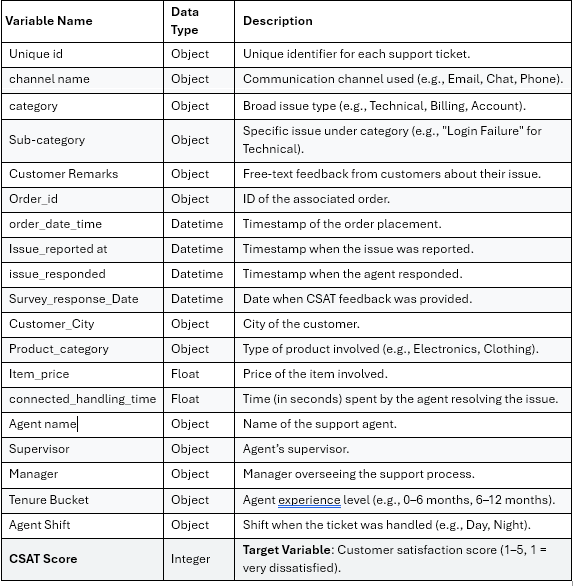

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()


,0
Unique id,85907
channel_name,3
category,12
Sub-category,57
Customer Remarks,18231
Order_id,67675
order_date_time,13766
Issue_reported at,30923
issue_responded,30262
Survey_response_Date,31


## 3. ***Data Wrangling***

### Data Wrangling Code

In [17]:
# Write your code to make your dataset analysis ready.

# Convert date columns to datetime type
datetime_cols = ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True, infer_datetime_format=True)

# Create a new feature for response time in minutes
df['response_time_minutes'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# Calculate and print the percentage of missing values per column
missing_pct = df.isnull().mean() * 100
print("Missing Percentage per Column:\n", missing_pct)

# Drop rows with missing values in the CSAT Score (target variable)
df = df.dropna(subset=['CSAT Score'])

# Convert specified columns to categorical type
categorical_cols = ['channel_name', 'category', 'Sub-category', 'Customer_City',
                    'Product_category', 'Agent_name', 'Supervisor', 'Manager',
                    'Tenure Bucket', 'Agent Shift']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Ensure CSAT Score is of integer type
df['CSAT Score'] = df['CSAT Score'].astype(int)

# Final check on data shape and a preview of the dataset
print("Data wrangling complete. Final dataset shape:", df.shape)
df.shape
df.dtypes

Missing Percentage per Column:
 Unique id                   0.000000
channel_name                0.000000
category                    0.000000
Sub-category                0.000000
Customer Remarks           66.542889
Order_id                   21.222950
order_date_time            79.962052
Issue_reported at           0.000000
issue_responded             0.000000
Survey_response_Date        0.000000
Customer_City              80.119199
Product_category           79.983005
Item_price                 79.971364
connected_handling_time    99.718300
Agent_name                  0.000000
Supervisor                  0.000000
Manager                     0.000000
Tenure Bucket               0.000000
Agent Shift                 0.000000
CSAT Score                  0.000000
response_time_minutes       0.000000
dtype: float64
Data wrangling complete. Final dataset shape: (85907, 21)


,0
Unique id,object
channel_name,category
category,category
Sub-category,category
Customer Remarks,object
Order_id,object
order_date_time,datetime64[ns]
Issue_reported at,datetime64[ns]
issue_responded,datetime64[ns]
Survey_response_Date,datetime64[ns]


### What all manipulations have you done and insights you found?

**Manipulations Done:-**

Converted date columns (order_date_time, Issue_reported at, issue_responded, Survey_response_Date) to datetime format.

Created a new feature: response_time_minutes = time difference (in minutes) between issue report and response.

Calculated and printed missing value percentages for all columns.

Dropped rows with missing values in the target column CSAT Score.

Converted key columns like channel_name, category, Customer_City, etc., to categorical type to optimize memory and prep for modeling.

Ensured CSAT Score is of integer type for proper classification.

Verified final dataset shape and previewed the dataset to ensure readiness.

**Insights Found:-**

Identified columns with high missing values that might need imputation or exclusion.

Feature response_time_minutes could be important for analyzing service responsiveness.

Presence of imbalanced classes in CSAT Score (based on earlier counts) could affect model performance and may need handling (e.g., resampling).

Potential for agent-level or channel-level performance insights by analyzing categorical variables.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

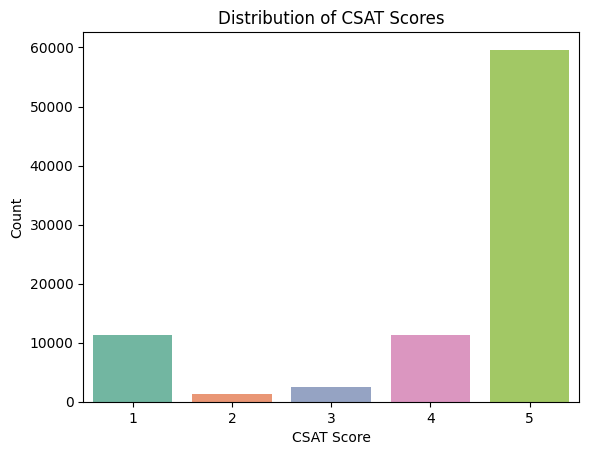

In [4]:
# Chart - 1 visualization code- CSAT Score Distribution

# Define the color palette for visualizations
palette = 'Set2'
# Visualize the distribution of CSAT Scores using a count plot
sns.countplot(data=df, x="CSAT Score", palette=palette)

# Add title and labels to the plot
plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

# Display the plot
plt.show()


##### 1. Why did you pick the specific chart?

The bar chart was picked because it perfectly displays the distribution of Customer Satisfaction (CSAT) scores in a clear and easily manner. It allows for quick comparison of the frequency of each score.

##### 2. What is/are the insight(s) found from the chart?

The chart found a strong positive skew, with the majority of responses being a score of 5, indicating high customer satisfaction. Lower scores, like 2 and 3, are much less frequent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight can enhance customer satisfaction strategies.Understanding that most customers are very satisfied can guide the business to maintain existing practices while focusing on areas of improvement for lower scores.

#### Chart - 2

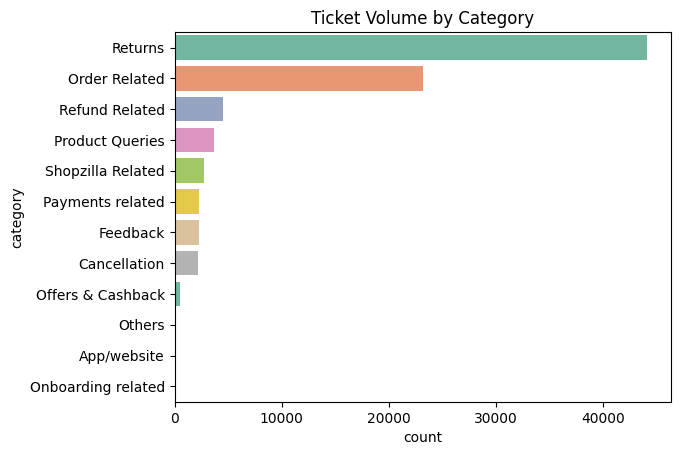

In [5]:
# Chart - 2 visualization code -Volume of Tickets by Category

# Visualize ticket volume by category using a count plot
sns.countplot(data=df, y="category", order=df['category'].value_counts().index, palette=palette)

# Add title to the plot
plt.title("Ticket Volume by Category")

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The horizontal bar chart was picked for its clear presentation of ticket volumes, aiding easy identification of high-interaction categories.

##### 2. What is/are the insight(s) found from the chart?

"Returns" and "Order Related" categories have the highest ticket volumes, indicating pain points. "Onboarding related" and "App/website" have the lowest volumes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

By focusing on reducing ticket volumes in high-traffic areas, the business can enhance efficiency and customer satisfaction, leading to better resource allocation.

#### Chart - 3

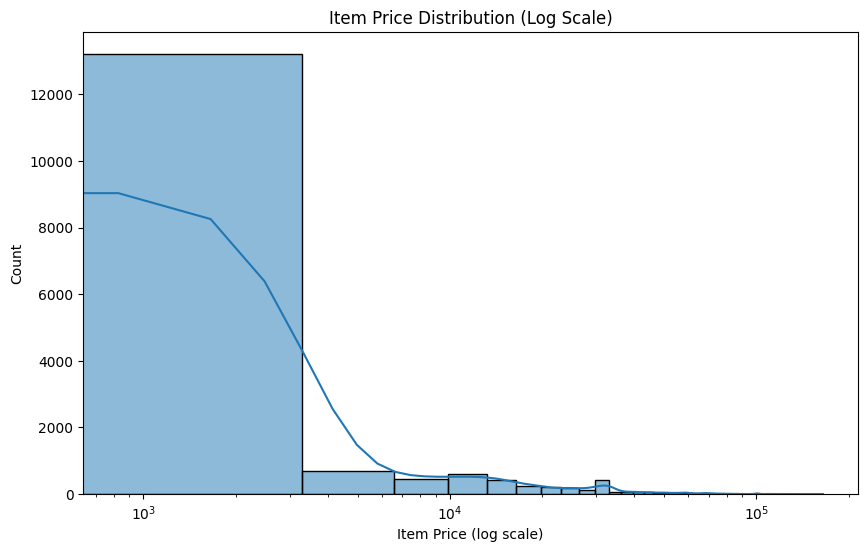

In [6]:
# Chart - 3 visualization code - Item Price Distribution

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot histogram with a log-scaled x-axis for better visualization of item price distribution
sns.histplot(data=df, x="Item_price", bins=50, kde=True)
plt.xscale('log')

# Add a title and label the x-axis
plt.title("Item Price Distribution (Log Scale)")
plt.xlabel("Item Price (log scale)")

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The histogram with a log scale is perfect for visualizing a wide range of item prices, highlighting the distribution and skewness effectively.

##### 2. What is/are the insight(s) found from the chart?

The majority of items are low-priced, with a steep decline as prices increase, showing a right-skewed distribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding pricing distributions can inform pricing strategies and inventory decisions, focusing on high-demand, lower-priced items to maximize sales.

#### Chart - 4

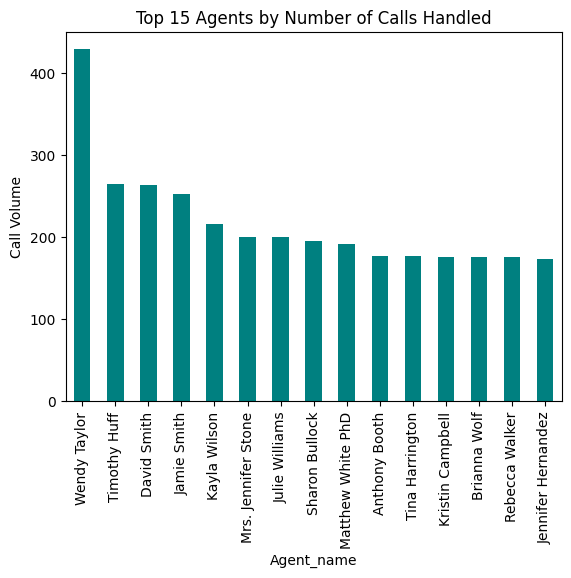

In [8]:
# Chart - 4 visualization code- Top 15 Agents by Number of Calls Handled

# Identify the top 15 agents by call volume
top_agents = df['Agent_name'].value_counts().head(15)

# Plot a bar chart of call volume for the top 15 agents
top_agents.plot(kind='bar', title='Top 15 Agents by Number of Calls Handled', color='Teal')

# Add a label for the y-axis
plt.ylabel("Call Volume")

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The bar chart effectively ranks agents by call volume, providing a clear visual of who handles the most calls.

##### 2. What is/are the insight(s) found from the chart?

Wendy Taylor leads with the highest call volume, indicating her significant contribution or high workload among agents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Redistributing calls can balance workloads, reduce burnout, and potentially improve service efficiency and employee satisfaction.

#### Chart - 5

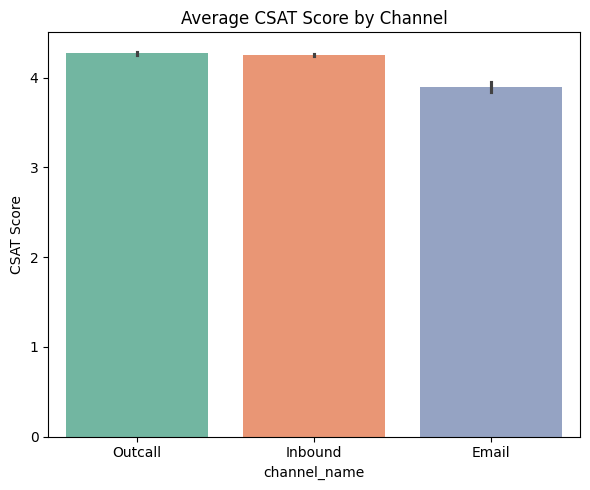

In [5]:
# Chart - 5 visualization code- Avg CSAT Score by Channel

# Calculate the mean CSAT Score for each channel and sort in descending order
mean_scores = df.groupby('channel_name')['CSAT Score'].mean().sort_values(ascending=False)

# Plot the sorted bar chart of mean CSAT Scores by channel
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x='channel_name', y='CSAT Score', order=mean_scores.index, palette=palette)

# Add title and labels to the plot
plt.title("Average CSAT Score by Channel")
plt.ylabel("CSAT Score")

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

This bar chart is suitable for comparing CSAT scores across different communication channels, allowing for a straightforward visual comparison.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the CSAT scores are relatively high for all channels, but there are differences. Outcall and Inbound channels have slightly higher satisfaction scores compared to Email.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

By understanding which channels perform better, the business can focus on enhancing the Email channel to match the satisfaction levels of others, potentially increasing overall satisfaction.

#### Chart - 6

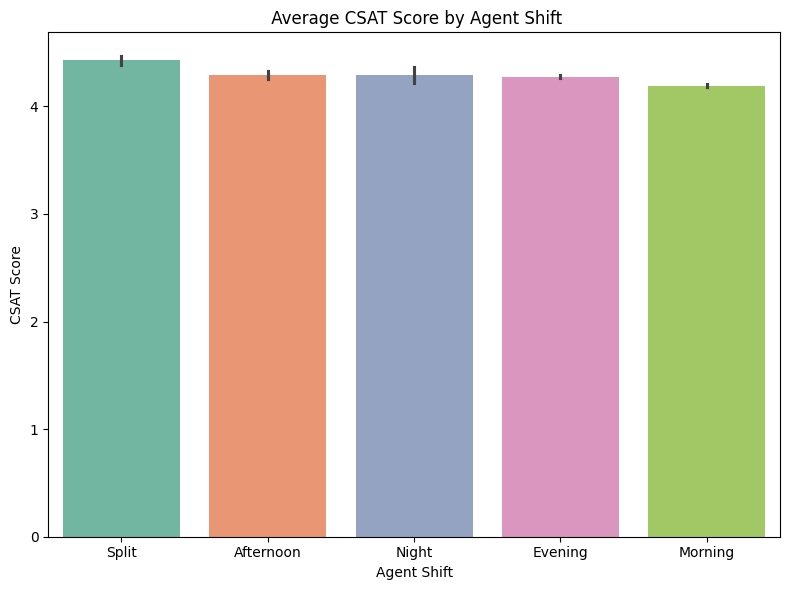

In [6]:
# Chart - 6 visualization code -Avg CSAT Score by Agent Shift

# Calculate the mean CSAT Score for each Agent Shift and sort in descending order
mean_scores = df.groupby('Agent Shift')['CSAT Score'].mean().sort_values(ascending=False)

# Plot the sorted bar chart of mean CSAT Scores by Agent Shift
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Agent Shift', y='CSAT Score', order=mean_scores.index, palette=palette)

# Add title and labels to the plot
plt.title(" Average CSAT Score by Agent Shift")  # Updated title to reflect correct subject
plt.ylabel("CSAT Score")

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The bar chart is an effective choice for comparing CSAT scores across different agent shifts, making shifts easily comparable.

##### 2. What is/are the insight(s) found from the chart?

All shifts have similar high CSAT scores, with minor variations. The Split shift appears to have a slightly higher satisfaction rating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding that Split shifts might slightly enhance customer satisfaction can guide scheduling decisions. Ensuring all shifts maintain high standards can improve overall customer experience.

#### Chart - 7

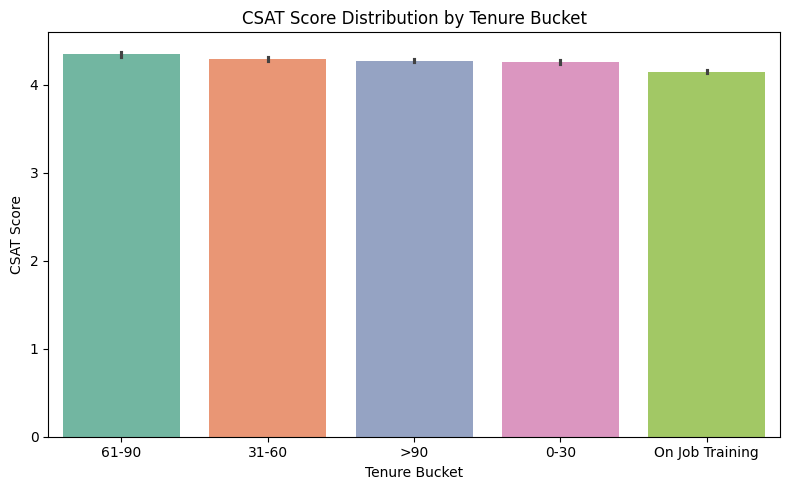

In [7]:
# Chart - 7 visualization code- Avg CSAT Score by Tenure Bucket

# Calculate the mean CSAT Score for each Tenure Bucket and sort in descending order
mean_scores = df.groupby('Tenure Bucket')['CSAT Score'].mean().sort_values(ascending=False)

# Plot the sorted bar chart of mean CSAT Scores by Tenure Bucket
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Tenure Bucket', y='CSAT Score', order=mean_scores.index, palette=palette)

# Add title and labels to the plot
plt.title("CSAT Score Distribution by Tenure Bucket")
plt.ylabel("CSAT Score")

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

This bar chart effectively compares CSAT scores across different employee tenure buckets, illustrating differences based on experience level.

##### 2. What is/are the insight(s) found from the chart?

CSAT scores are consistently high across all tenure buckets, with slight differences. Longer tenure shows marginally higher satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Recognizing that longer tenure correlates with slightly better scores can guide investment in employee development and retention to sustain high satisfaction levels.

#### Chart - 8

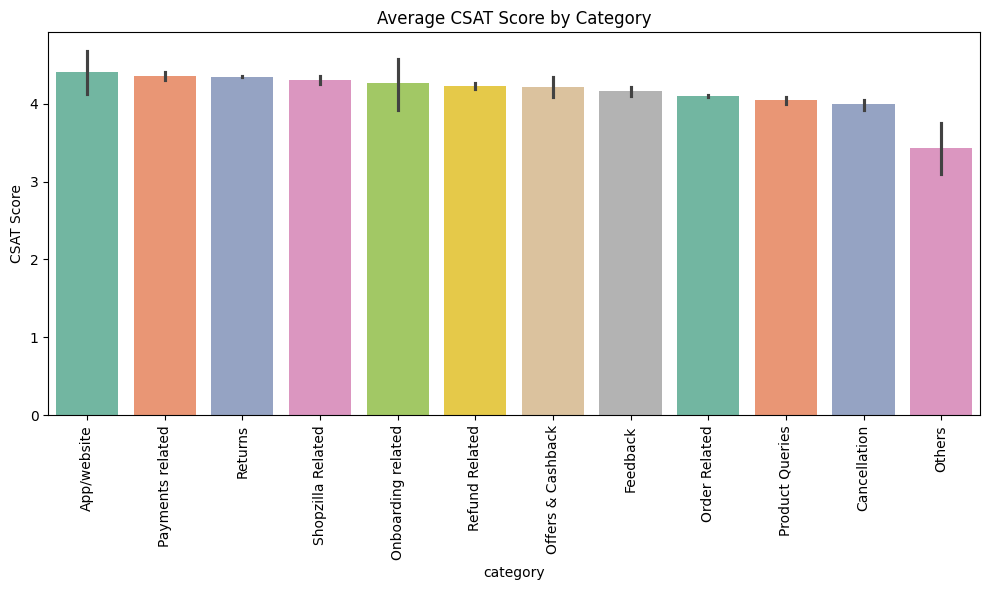

In [12]:
# Chart - 8 visualization code - Avg CSAT Score by Category

# Calculate the mean CSAT Score for each category and sort in descending order
mean_scores = df.groupby('category')['CSAT Score'].mean().sort_values(ascending=False)

# Plot the bar chart of mean CSAT Scores by category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='category', y='CSAT Score', order=mean_scores.index, palette='Set2')

# Add title, rotate x-axis labels, and ylabel
plt.title("Average CSAT Score by Category")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.ylabel("CSAT Score")

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The bar chart is ideal for comparing CSAT scores across multiple categories, clearly showing differences in customer satisfaction by category.

##### 2. What is/are the insight(s) found from the chart?

Scores are generally high across categories, but "Others" has noticeably lower satisfaction. Categories like "App/Website" and "Onboarding" perform well.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

By identifying lower satisfaction in the "Others" category, targeted efforts can be made to address specific issues, improving overall customer satisfaction and experience.

#### Chart - 9

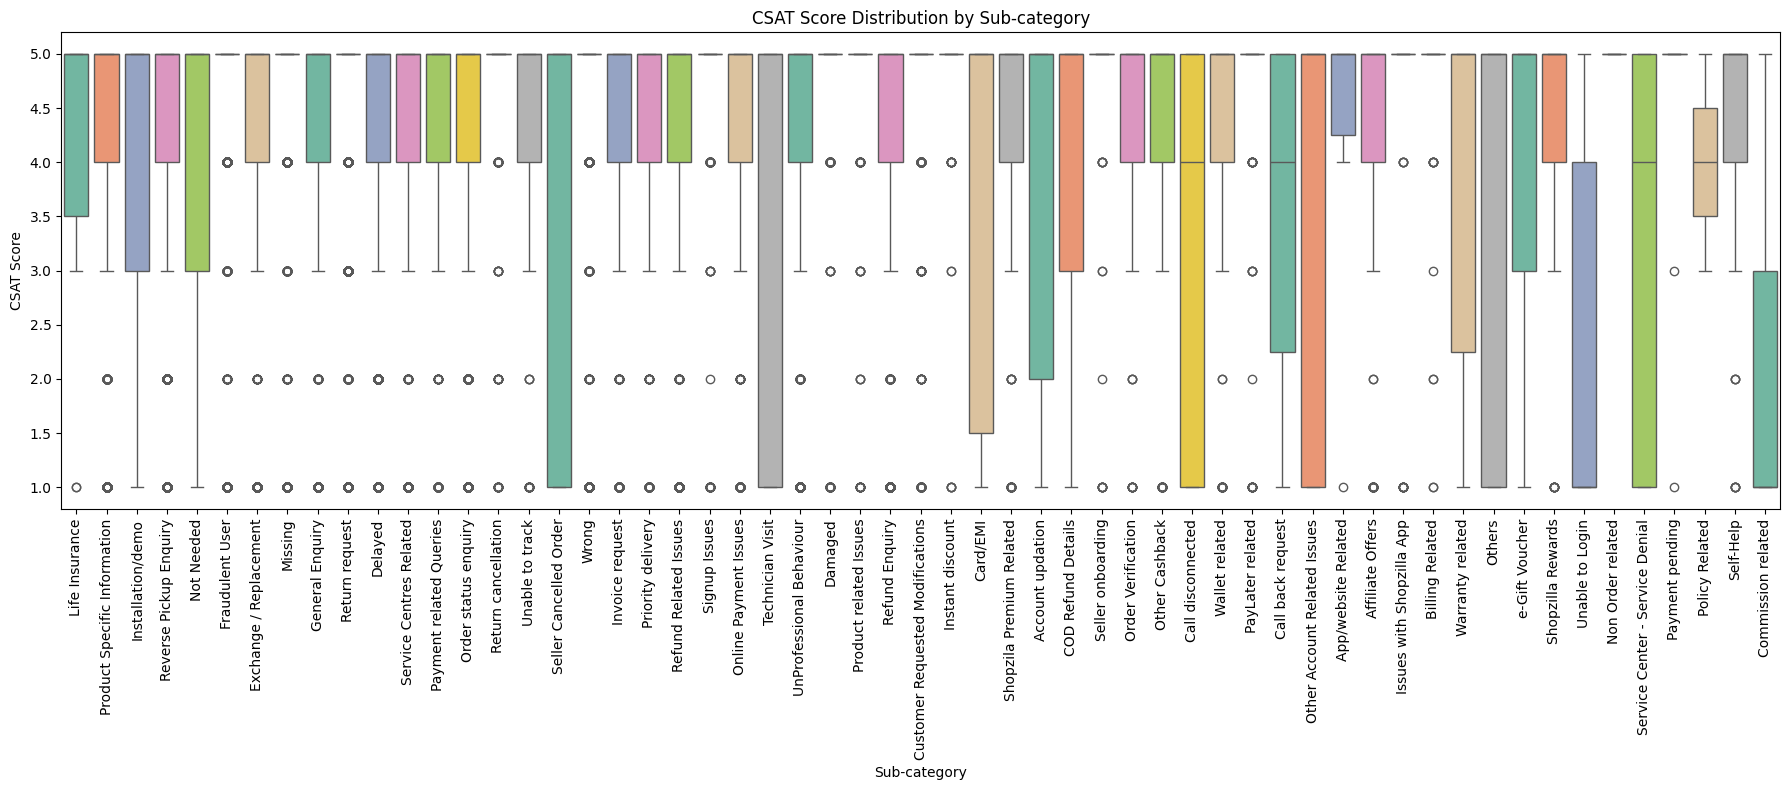

In [13]:
# Chart - 9 visualization code - Avg CSAT Score by Sub-category

# Set the figure size to be wider to accommodate all sub-categories
plt.figure(figsize=(18, 8))

# Create a box plot for CSAT Score distribution by Sub-category
sns.boxplot(data=df, x='Sub-category', y='CSAT Score', palette=palette)

# Add title and labels to the plot
plt.title("CSAT Score Distribution by Sub-category")
plt.xticks(rotation=90)  # Rotate x-axis labels for clarity
plt.xlabel("Sub-category")
plt.ylabel("CSAT Score")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The box plot is effective for showing the distribution and variability of CSAT scores across sub-categories, highlighting medians and outliers.

##### 2. What is/are the insight(s) found from the chart?

There is significant variability in CSAT scores across sub-categories. Some have high median scores while others show a wider spread and lower scores, indicating areas needing improvement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying sub-categories with lower scores and higher variability can direct targeted improvements, enhancing overall customer satisfaction and service quality.

#### Chart - 10

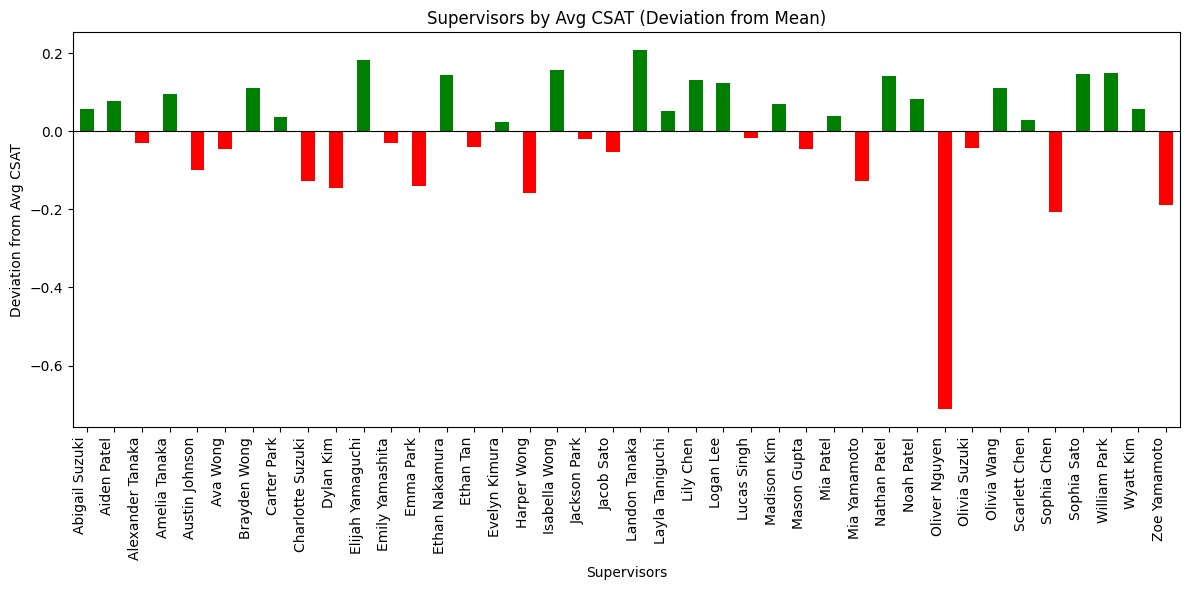

In [14]:
# Chart - 10 visualization code -  Supervisors by Avg CSAT (Deviation from Mean)

# Calculate average CSAT score per supervisor
supervisor_scores = df.groupby('Supervisor')['CSAT Score'].mean()

# Calculate deviation of each supervisor's score from the overall mean
deviation = supervisor_scores - supervisor_scores.mean()

# Plot the deviation of average CSAT scores by supervisor
plt.figure(figsize=(12, 6))
ax = deviation.plot(kind='bar', color=['red' if x < 0 else 'green' for x in deviation])

# Add a horizontal line at zero for reference
plt.axhline(0, color='black', linewidth=0.8)

# Add title and labels to the plot
plt.title('Supervisors by Avg CSAT (Deviation from Mean)')
plt.xlabel('Supervisors')
plt.ylabel("Deviation from Avg CSAT")

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The bar chart effectively shows supervisors' CSAT performance compared to the average, highlighting deviations clearly.

##### 2. What is/are the insight(s) found from the chart?

Some supervisors consistently perform above average, while others fall below, indicating variation in team management effectiveness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying top and underperforming supervisors can lead to targeted training and resource allocation, improving overall customer satisfaction and team performance.

#### Chart - 11

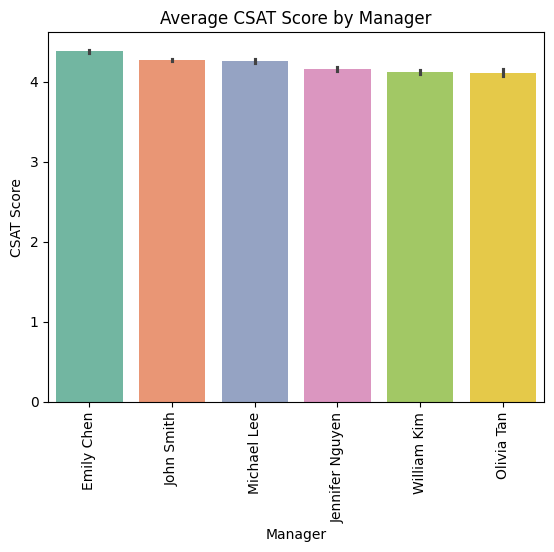

In [15]:
# Chart - 11 visualization code - Avg CSAT Score per Manager

# Calculate the mean CSAT Score for each Manager and sort in descending order
mean_scores = df.groupby('Manager')['CSAT Score'].mean().sort_values(ascending=False)

# Create a bar plot of mean CSAT Scores by Manager
sns.barplot(data=df, x='Manager', y='CSAT Score', order=mean_scores.index, palette=palette)

# Add title and rotate x-axis labels for better readability
plt.title("Average CSAT Score by Manager")
plt.xticks(rotation=90)

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

This bar chart effectively compares CSAT scores across individual employees, allowing for performance assessment.

##### 2. What is/are the insight(s) found from the chart?

All individuals maintain high CSAT scores, with some minor variations. Emily Chen leads slightly in customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Recognizing top performers like Emily Chen can inform best practices and  learning, benefiting overall team performance and customer satisfaction.

#### Chart - 12

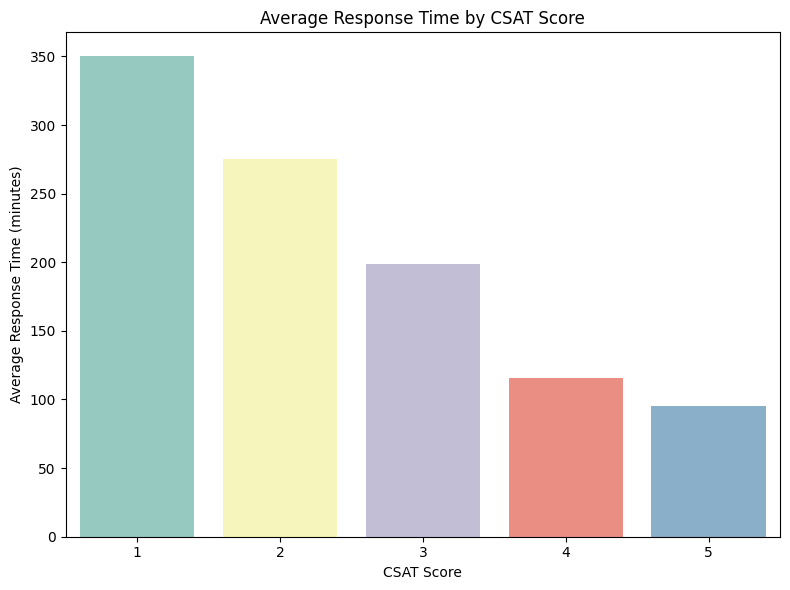

In [18]:
# Chart - 12 visualization code - Avg Response Time vs CSAT Score

# Calculate average response time for each CSAT Score
average_response_time = df.groupby('CSAT Score')['response_time_minutes'].mean().reset_index()

# Plot the average response time by CSAT Score
plt.figure(figsize=(8, 6))
sns.barplot(data=average_response_time, x='CSAT Score', y='response_time_minutes', palette='Set3')

# Add title and labels to the plot
plt.title('Average Response Time by CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Average Response Time (minutes)')

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

This bar chart clearly shows the relationship between CSAT scores and average response times, making it easy to see trends.

##### 2. What is/are the insight(s) found from the chart?

There is a clear inverse relationship between response time and satisfaction. Faster response times correlate with higher CSAT scores.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

By focusing on reducing response times, the business can potentially increase customer satisfaction, improving overall service quality and perception.

#### Chart - 13

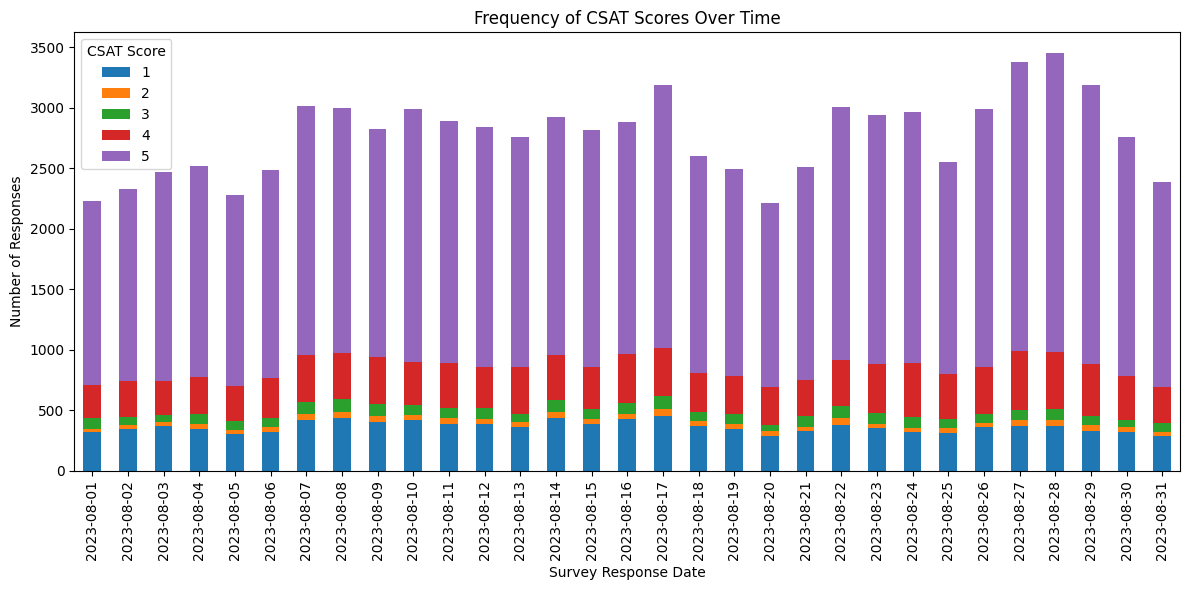

In [19]:
# Chart - 13 visualization code - Frequency of CSAT Scores Over Time

# Convert Survey Response Date to date format
df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date']).dt.date

# Count the frequency of each CSAT Score per survey date
freq = df.groupby(['Survey_response_Date', 'CSAT Score']).size().unstack(fill_value=0)

# Plot a stacked bar chart for CSAT Score frequencies over time
freq.plot(kind='bar', stacked=True, figsize=(12, 6))

# Add title and labels to the plot
plt.title('Frequency of CSAT Scores Over Time')
plt.xlabel('Survey Response Date')
plt.ylabel('Number of Responses')

# Add a legend with a title
plt.legend(title='CSAT Score')

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

The stacked bar chart shows CSAT score distribution over time, making it easy to track trends and fluctuations.

##### 2. What is/are the insight(s) found from the chart?

High satisfaction scores (5s) are consistently dominant each day, while lower scores are less frequent, indicating overall positive customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Maintaining high satisfaction over time ensures customer loyalty and can help identify specific days or trends that need attention for continuous improvement.

#### Chart - 14 - Correlation Heatmap

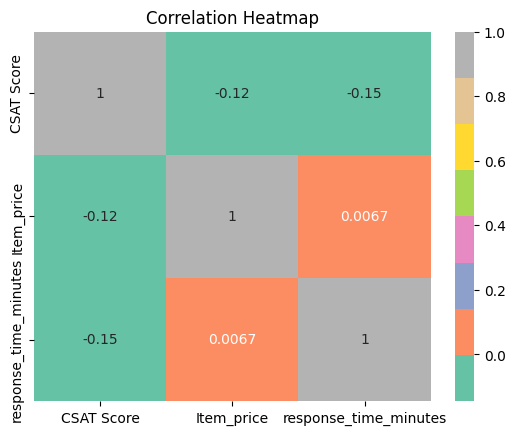

In [20]:
# Correlation Heatmap visualization code

# Calculate correlation matrix for specified columns
corr = df[["CSAT Score", "Item_price", "response_time_minutes"]].corr()

# Visualize the correlations with a heatmap
sns.heatmap(corr, annot=True, cmap='Set2')

# Add title to the heatmap
plt.title("Correlation Heatmap")

# Show the plot
plt.show()

##### 1. Why did you pick the specific chart?

The heatmap clearly visualizes correlations between variables, highlighting relationships through color intensity.

##### 2. What is/are the insight(s) found from the chart?

**The correlation heatmap shows:**

**Price Sensitivity:** Higher item prices slightly correlate with lower satisfaction, possibly due to increased customer expectations.

**Response Time Impact:** Longer response times have a modest negative effect on satisfaction, highlighting the importance of prompt service.

**Handling Time:** Minimal correlation suggests handling time doesn't directly affect satisfaction.

Overall, these weak correlations suggest other factors likely influence CSAT, pointing to service quality and communication as key improvement areas.

#### Chart - 15 - Pair Plot

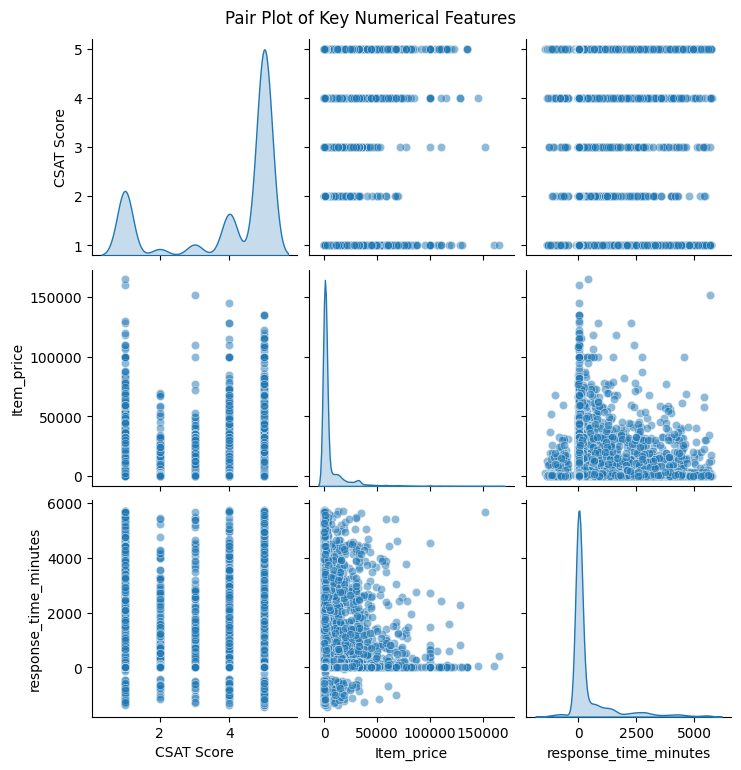

In [21]:
# Pair Plot visualization code

# Filter valid numerical rows
selected_cols = ["CSAT Score", "Item_price", "response_time_minutes"]
df_pairplot = df[selected_cols].apply(pd.to_numeric, errors='coerce')
df_pairplot = df_pairplot[np.isfinite(df_pairplot).all(axis=1)]

# Generate the pairplot
sns.pairplot(df_pairplot, kind="scatter", diag_kind="kde", plot_kws={'alpha': 0.5})
plt.suptitle("Pair Plot of Key Numerical Features", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

The pairplot is chosen to visualize relationships and distributions among multiple variables simultaneously, enabling a broad understanding of how factors like CSAT Score, Item Price, Handling Time, and Response Time interact.

##### 2. What is/are the insight(s) found from the chart?

From the plot, it is evident that CSAT Scores cluster around certain values, price and time variables are heavily skewed with many low and some extreme values, and there is no obvious direct correlation between CSAT Score and the other variables, suggesting that customer satisfaction is influenced by a complex mix of factors.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

These above insights are directly actionable. By accurately identifying dissatisfied users in advance, Client can:

*   Proactively intervene with high-risk tickets.
*   Enhance agent training and performance targeting key pain points.
*   Improve overall customer retention and satisfaction.








# **Conclusion**

This project aimed to develop a robust classification model to predict customer satisfaction scores (CSAT) using Flipkart's historical support interaction data. By addressing challenges like class imbalance and varied feature types, we explored multiple algorithms and fine-tuned them for optimal performance.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***